In [1]:
import os
os.chdir('./stat_csv')
os.getcwd()

'/home/tako/Kasetsart/statistics/stat_csv'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [3]:
from sklearn.model_selection import train_test_split

### Load Dataset

In [4]:
orig_df = pd.read_excel("Dry_Bean_Dataset.xlsx")
orig_df.head(10)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
5,30279,634.927,212.560556,181.510182,1.171067,0.520401,30600,196.347702,0.775688,0.989510,0.943852,0.923726,0.007020,0.003153,0.853270,0.999236,SEKER
6,30477,670.033,211.050155,184.039050,1.146768,0.489478,30970,196.988633,0.762402,0.984081,0.853080,0.933374,0.006925,0.003242,0.871186,0.999049,SEKER
7,30519,629.727,212.996755,182.737204,1.165591,0.513760,30847,197.124320,0.770682,0.989367,0.967109,0.925480,0.006979,0.003158,0.856514,0.998345,SEKER
8,30685,635.681,213.534145,183.157146,1.165852,0.514081,31044,197.659696,0.771561,0.988436,0.954240,0.925658,0.006959,0.003152,0.856844,0.998953,SEKER
9,30834,631.934,217.227813,180.897469,1.200834,0.553642,31120,198.139012,0.783683,0.990810,0.970278,0.912125,0.007045,0.003008,0.831973,0.999061,SEKER


In [5]:
orig_df.columns

Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4', 'Class'],
      dtype='object')

In [6]:
orig_df.dtypes

Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class               object
dtype: object

In [7]:
orig_df['Class'].unique()

array(['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON'],
      dtype=object)

In [8]:
df = orig_df.copy()

In [9]:
orig_X = df.drop(['Class'], axis=1)
orig_X.columns

Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4'],
      dtype='object')

In [10]:
# Finding numerical variables
num_features = orig_X.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_features

['Area',
 'Perimeter',
 'MajorAxisLength',
 'MinorAxisLength',
 'AspectRation',
 'Eccentricity',
 'ConvexArea',
 'EquivDiameter',
 'Extent',
 'Solidity',
 'roundness',
 'Compactness',
 'ShapeFactor1',
 'ShapeFactor2',
 'ShapeFactor3',
 'ShapeFactor4']

### Scaling

In [11]:
# Scale by standardized normal distribution, (x-mean)/sd
def scale_standard(X_train, X_test):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# Scale by min-max, (x-min)/(max-min)
def scale_minmax(X_train, X_test):
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# Scale by robust, (x-median)/iqr
def scale_minmax(X_train, X_test):
    from sklearn.preprocessing import RobustScaler
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

### Encoding Categorical Data

In [12]:
# One-Hot Encoder version 1: convert all categorical variables
def onehot_encoder_all(df):
    from sklearn.preprocessing import OneHotEncoder
    onehot_encoder = OneHotEncoder(sparse_output=False,        # use sparse=True for large data
                                    handle_unknown='ignore')
    oh_encoded = onehot_encoder.fit_transform(df)
    ohe_df = pd.DataFrame(oh_encoded,
                         columns=onehot_encoder.get_feature_names_out(df.columns))
    return ohe_df

# One-Hot Encoder version 2: Convert selected variables
def onehot_encoder_selected(df, encoded_vars):
    df = pd.get_dummies(df, columns=encoded_vars, drop_first=False)
    return df

# Label Encoder
def label_encoder(df, encoded_var):
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    df[encoded_var] = label_encoder.fit_transform(df[encoded_var])
    return df

# Ordinal Encoder
def ordinal_encoder(df, encoded_var, encode_order):
    from sklearn.preprocessing import OrdinalEncoder
    ordinal_encoder = OrdinalEncoder(categories=[encode_order])
    df[encoded_var] = ordinal_encoder.fit_transform(df[[encoded_var]])
    return df

In [13]:
# Frequenct Encoder
def frequent_encoder(df, encoded_var):
    freq_encoding = df[encoded_var].value_counts() 
    df[encoded_var] = df[encoded_var].map(freq_encoding)
    return df

# Target Encoder
def target_encoder(df, encoded_var, encoded_num):
    import category_encoders as ce
    target_encoder = ce.TargetEncoder(cols=[encoded_var])
    df[encoded_var] = target_encoder.fit_transform(df[encoded_var], df[encoded_num])
    return df

# Binary Encoder
def binary_encoder(df, encoded_var):
    import category_encoders as ce
    binary_encoder = ce.BinaryEncoder(cols=[encoded_var])
    df_binary = binary_encoder.fit_transform(df[encoded_var])
    df_binary.columns = [f"{encoded_var}_bin_{i}" for i in range(df_binary.shape[1])]
    df = pd.concat([df, df_binary], axis=1)
    df = df.drop([encoded_var], axis=1)
    return df 

### Hash Encoder
def hash_encoder(df, encoded_var, hash_len):
    import category_encoders as ce
    hash_encoder = ce.HashingEncoder(cols=[encoded_var], n_components=hash_len)  # n_components = length of hash, default = 8
    df_hash = hash_encoder.fit_transform(df[encoded_var])
    df_hash.columns = [f"{encoded_var}_hash_{i}" for i in range(df_hash.shape[1])]
    df = pd.concat([df, df_hash], axis=1)
    df = df.drop([encoded_var], axis=1)
    return df 

### Handling Imbalance

In [14]:
# Undersampling
def undersampling(X,y):
    from imblearn.under_sampling import RandomUnderSampler
    X_res, y_res = RandomUnderSampler().fit_resample(X, y)
    return X_res, y_res

# Oversampling
def oversampling(X,y):
    from imblearn.over_sampling import RandomOverSampler
    X_res, y_res = RandomOverSampler().fit_resample(X, y)
    return X_res, y_res

# SMOTE
def smote(X,y):
    from imblearn.over_sampling import SMOTE
    X_res, y_res = SMOTE().fit_resample(X, y)
    return X_res, y_res

### Performance Evaluation

In [15]:
# Function to compute performance classification metrics
def evaluate_performance(y_true, y_pred, average_val='macro'):

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average=average_val)
    recall = recall_score(y_true, y_pred, average=average_val)
    f1 = f1_score(y_true, y_pred, average=average_val)

    from sklearn.metrics import confusion_matrix
    confusion = confusion_matrix(y_true, y_pred)

    return accuracy, precision, recall, f1, confusion

In [16]:
def plot_roc_auc(y_true, y_pred):
    from sklearn.metrics import roc_curve, roc_auc_score
    import matplotlib.pyplot as plt

    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred)

    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve (AUC = {auc:.3f})")
    plt.show()

    return auc

### Check Feature Importance

In [17]:
def get_permutation_importance(model, X, X_true, y_true):
    from sklearn.inspection import permutation_importance
    result = permutation_importance(model, X_test, y_test, n_repeats=10)
    
    perm_df = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False)
    
    return perm_df

    # Higher value = more important feature, relatively compared to other features
    # Near-zero value = unimportant feature, relatively compared to other features
    # Negative value = noisy feature

In [18]:
def create_shap_values_plot(model, X, X_train, X_test):
    import shap
    X_train_df = pd.DataFrame(X_train, columns=X.columns.tolist())
    X_test_df = pd.DataFrame(X_test, columns=X.columns.tolist())
    if len(X_train) > 200:
        explainer = shap.KernelExplainer(model.predict, X_train_df.sample(200))
    else: 
        explainer = shap.KernelExplainer(model.predict, X_train_df)
    if len(X_test) > 100:
        shap_values = explainer.shap_values(X_test_df.sample(100))
        shap.summary_plot(shap_values, X_test_df.sample(100))
    else:
        shap_values = explainer.shap_values(X_test_df)
        shap.summary_plot(shap_values, X_test_df)

### Experiments: Interpretability

In [19]:
## Ordinal -> Label Encoder
encoded_var = 'Class'
df = label_encoder(df, encoded_var)
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,5
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,5
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,5
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,5
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,5


In [20]:
orig_y = df['Class']
orig_y 

0        5
1        5
2        5
3        5
4        5
        ..
13606    3
13607    3
13608    3
13609    3
13610    3
Name: Class, Length: 13611, dtype: int64

In [21]:
X = orig_X.copy()
y = orig_y.copy()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

############## Imbalance Handling here ##############
# Smote Example
X_train, y_train = smote(X_train,y_train)
print(X_train.shape, y_train.shape)
y_train.value_counts()
#######################################################

base_X_train = X_train.copy()
base_X_test = X_test.copy()

base_X_train.head()

(20125, 16) (20125,)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,29076,636.353,235.061516,158.033619,1.487415,0.740272,29490,192.407674,0.693524,0.985961,0.902295,0.818542,0.008084,0.002239,0.670011,0.996584
1,38091,755.186,271.077683,179.756984,1.508023,0.748513,38716,220.224811,0.706318,0.983857,0.839314,0.812405,0.007117,0.001912,0.660002,0.995298
2,30969,651.527,230.164083,171.903953,1.338911,0.664964,31318,198.572293,0.733689,0.988856,0.916795,0.862742,0.007432,0.002540,0.744324,0.996584
3,34589,685.425,253.001232,174.609358,1.448956,0.723664,34965,209.857291,0.784331,0.989246,0.925184,0.829471,0.007314,0.002136,0.688023,0.996915
4,35954,710.093,251.660769,182.014822,1.382639,0.690581,36380,213.958067,0.794564,0.988290,0.896038,0.850184,0.007000,0.002256,0.722814,0.999390


### Baseline Model

In [22]:
X_train = base_X_train.copy()
X_test = base_X_test.copy()

# Scaling is not needed for tree-based classification method

#######################################################
# Construct a model
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
model.fit(X_train, y_train)
#######################################################

# Use model for predicted responses
y_pred = model.predict(X_test)

acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
print(confusion)
print(acc, precision, recall, f1)

[[228   0  21   0   1   3   8]
 [  0 117   0   0   0   0   0]
 [ 22   0 284   0   9   1   1]
 [  0   0   0 574   9   7  81]
 [  5   0   8   4 383   0   8]
 [  6   0   1  12   0 381  13]
 [  6   0   4  47   9  10 460]]
0.8912963643040764 0.9047645889822575 0.9063363599385296 0.905304518778298


In [23]:
# Get summary of classification report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86       261
           1       1.00      1.00      1.00       117
           2       0.89      0.90      0.89       317
           3       0.90      0.86      0.88       671
           4       0.93      0.94      0.94       408
           5       0.95      0.92      0.93       413
           6       0.81      0.86      0.83       536

    accuracy                           0.89      2723
   macro avg       0.90      0.91      0.91      2723
weighted avg       0.89      0.89      0.89      2723



In [24]:
# Question: Rank classes that perform the best to the worst based on the results above.
# Answer and provide the reason: By comparing precision, recall, f1-score in each rank classes
#                                Class: 1 > 4 > 5 > 2 > 0 > 3 > 6

In [25]:
#### Find average AUC for each class
#### ROC–AUC for multiclass classification is computed using a one-vs-rest strategy.

In [26]:
y_test

1488     5
2611     0
749      5
99       5
11298    3
        ..
2884     0
532      5
10926    3
4676     2
7760     6
Name: Class, Length: 2723, dtype: int64

In [27]:
# Treat every class as binary => Binarize labels in a one-vs-rest
num_classes = 7
from sklearn.preprocessing import label_binarize
y_bin = label_binarize(y_test, classes=list(range(0, num_classes, 1)))  
print(y_bin)
print(y_bin.shape)

[[0 0 0 ... 0 1 0]
 [1 0 0 ... 0 0 0]
 [0 0 0 ... 0 1 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 [0 0 0 ... 0 0 1]]
(2723, 7)


In [28]:
# Derive predicted probabilities
y_pred = model.predict_proba(X_test)
print(y_pred)
print(y_pred.shape)

[[0. 0. 0. ... 0. 1. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(2723, 7)


In [29]:
# Compute AUC 
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    from sklearn.metrics import roc_curve, auc
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_pred[:,i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), y_pred.ravel())  # treat every class as binary and flatten
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
# Micro AUC indicates how good is the model overall, weighted by class frequency
# If micro-AUC is high, the model is good at ranking the correct class higher than incorrect ones
#                       performance is strong on frequent classes

# Macro-average: average AUC across classes
roc_auc["macro"] = np.mean(list(roc_auc.values()))  # Averages AUC for each class equally
# Macro AUC indicates how well the model performs on an average class
# If macro-AUC is low, the model struggles on minority classes
roc_auc

{0: 0.9288612192685136,
 1: 1.0,
 2: 0.9408838576534478,
 3: 0.9123689439694617,
 4: 0.9633152288993352,
 5: 0.9567136253576932,
 6: 0.9037272485310076,
 'micro': 0.9365895458440445,
 'macro': np.float64(0.9428074586904379)}

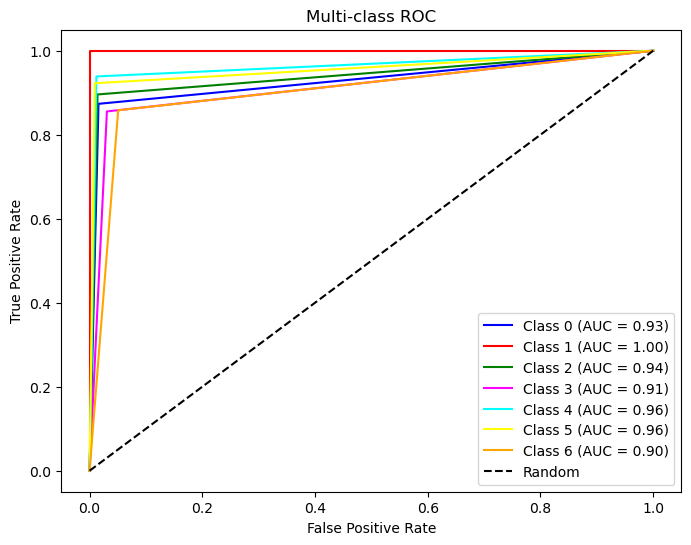

In [30]:
plt.figure(figsize=(8,6))

colors = ['blue', 'red', 'green', 'magenta', 'cyan', 'yellow', 'orange']

for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC')
plt.legend()
plt.show()

In [31]:
# Question: Rank the classes from the best to the worst based on AUC for each class.
#           Compare this ranking with the ranking obtained from previous question (based on precision, recall, F1-scores), 
#           are the rankings from (1) AUC and (2) precision/recall/F1-scores generally similar or noticeably different?
# Answer and provide the reason: Class: 1 > 4 > 5 > 2 > 0 > 3 > 6 which is the same ranking as from performace metric (based on precision, recall, F1-scores)
# 0: 0.9409647329056837
# 1: 1.0
# 2: 0.9480242611137771
# 3: 0.9201208228386831
# 4: 0.9615826028035405
# 5: 0.9524323134492626
# 6: 0.8980935514471537

In [32]:
get_permutation_importance(model, base_X_train, X_test, y_test)

,feature,importance_mean,importance_std
12,ShapeFactor1,0.285457,0.004254
2,MajorAxisLength,0.263606,0.006348
14,ShapeFactor3,0.191590,0.005967
3,MinorAxisLength,0.189754,0.004543
11,Compactness,0.186082,0.002868
1,Perimeter,0.164855,0.005714
13,ShapeFactor2,0.131032,0.003985
4,AspectRation,0.122916,0.002699
10,roundness,0.120198,0.005804
6,ConvexArea,0.086118,0.004040


Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/100 [00:00<?, ?it/s]

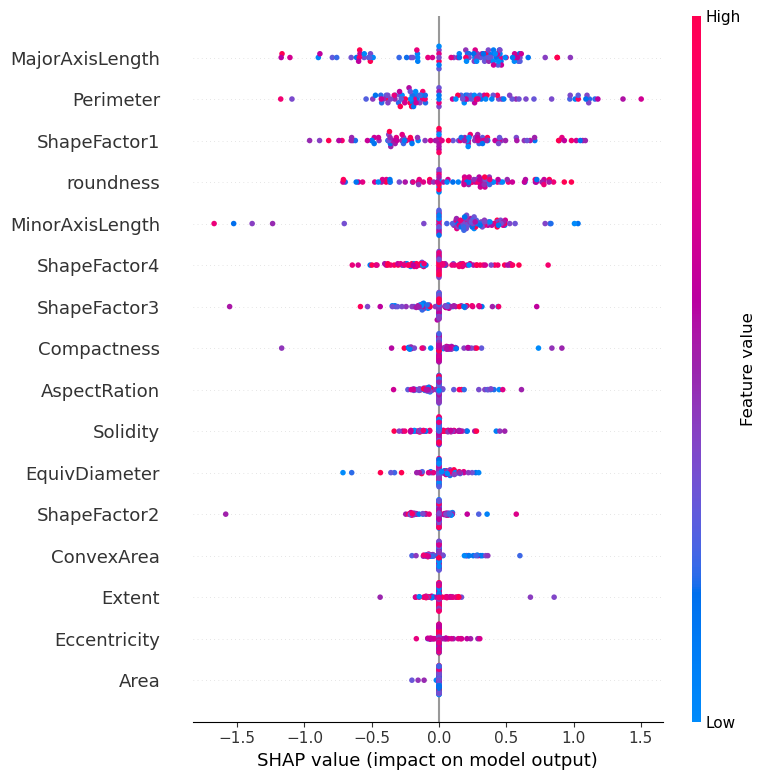

In [33]:
create_shap_values_plot(model, base_X_train, base_X_train, X_test)

### Cross Validation

In [34]:
############## Imbalance Handling here ##############
# Smote Example
#X_train, y_train = smote(X_train,y_train)
#print(X_train.shape, y_train.shape)
#y_train.value_counts()
#######################################################

In [35]:
#### KFold + Cross Validation
X = orig_X.copy()
y = orig_y.copy()

# Scaling is not needed for tree-based classification method

#######################################################
# Construct a model
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion = 'gini', class_weight='balanced', random_state = 0)  
# Note: class_weight='balanced' = handling imbalance classes here
#######################################################

#######################################################
# Set up KFold + Cross Validation 
from sklearn.model_selection import KFold, cross_validate
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
#######################################################

scoring = {
    'accuracy': 'accuracy',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'f1_weighted': 'f1_weighted'
}

#######################################################
# Train and run models using KFold + Cross Validation option
cv_results = cross_validate(model, X, y, cv=kfold, scoring=scoring)
#######################################################

for metric in scoring.keys():
    print(f"{metric}: {cv_results['test_'+metric].mean():.4f}")

cv_results

accuracy: 0.8959
precision_weighted: 0.8967
recall_weighted: 0.8959
f1_weighted: 0.8960


{'fit_time': array([0.19835472, 0.21287203, 0.20173788, 0.20121574, 0.21743751]),
 'score_time': array([0.00716686, 0.00620317, 0.00573683, 0.00624299, 0.00660443]),
 'test_accuracy': array([0.90268087, 0.89933872, 0.89346069, 0.89566495, 0.88831741]),
 'test_precision_weighted': array([0.9031995 , 0.9012149 , 0.89405667, 0.89592286, 0.88892278]),
 'test_recall_weighted': array([0.90268087, 0.89933872, 0.89346069, 0.89566495, 0.88831741]),
 'test_f1_weighted': array([0.90287443, 0.89984867, 0.89332894, 0.89570953, 0.88845214])}

In [36]:
#### StratifiedKFold + Cross Validation

X = orig_X.copy()
y = orig_y.copy()

# Scaling is not needed for tree-based classification method

#######################################################
# Construct a model
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion = 'gini', class_weight='balanced', random_state = 0)
# Note: class_weight='balanced' = handling imbalance classes here
#######################################################

#######################################################
# Set up StratifiedKFold + Cross Validation
from sklearn.model_selection import StratifiedKFold, cross_validate
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#######################################################

scoring = {
    'accuracy': 'accuracy',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'f1_weighted': 'f1_weighted'
}

#######################################################
# Train and run models using StratifiedKFold + Cross Validation option
cv_results = cross_validate(model, X, y, cv=stratified_kfold, scoring=scoring)
#########################################################

#######################################################
#  Get performance of all folds at once
for metric in scoring.keys():
    print(f"{metric}: {cv_results['test_'+metric].mean():.4f}")

cv_results

accuracy: 0.8988
precision_weighted: 0.8992
recall_weighted: 0.8988
f1_weighted: 0.8989


{'fit_time': array([0.2125299 , 0.20416212, 0.20994401, 0.19211316, 0.20100975]),
 'score_time': array([0.00639653, 0.00659823, 0.00688362, 0.00614238, 0.00626111]),
 'test_accuracy': array([0.88762394, 0.90742101, 0.89639971, 0.90044085, 0.90191036]),
 'test_precision_weighted': array([0.88855732, 0.90832193, 0.89650351, 0.90033639, 0.90203893]),
 'test_recall_weighted': array([0.88762394, 0.90742101, 0.89639971, 0.90044085, 0.90191036]),
 'test_f1_weighted': array([0.88796082, 0.90770449, 0.89640361, 0.90034309, 0.90194154])}

In [37]:
# Question: Compare accuracy, precision, recall, F1-scores of models using
#           (1) KFold or (2) StratifiedKFold 
#           which one (1) or (2) has better performance?
# Answer and provide the reason: Overall StratifiedKFold has better performance as it should separate more evenly on dataset
# KFold                                     StratifiedKFold
# accuracy: 0.8959                          accuracy: 0.8988
# precision_weighted: 0.8967                precision_weighted: 0.8992
# recall_weighted: 0.8959                   recall_weighted: 0.8988
# f1_weighted: 0.8960                       f1_weighted: 0.8989

In [38]:
#### StratifiedKFold + Cross Validation
#### Get performance of each fold separately 

X_train = base_X_train.copy()
X_test = base_X_test.copy()

# Scaling is not needed for tree-based classification method

#######################################################
# Construct a model
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion = 'gini', class_weight='balanced', random_state = 0)
# Note: class_weight='balanced' = handling imbalance classes here
#######################################################

#######################################################
# Set up StratifiedKFold + Cross Validation
from sklearn.model_selection import StratifiedKFold, cross_validate
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#######################################################

scoring = {
    'accuracy': 'accuracy',
    'f1_weighted': 'f1_weighted',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted'
}

#######################################################
# Train and run models for each fold separately
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

for fold, (train_idx, test_idx) in enumerate(stratified_kfold.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
    print(f"Fold {fold}: ")
    print(confusion)
    print(acc, precision, recall, f1)
#########################################################


Fold 1: 
[[227   0  20   0   6   5   6]
 [  0 105   0   0   0   0   0]
 [ 19   0 294   0   8   0   5]
 [  0   0   0 624   1  14  71]
 [  4   0  10   3 356   0  12]
 [  3   0   2  23   0 366  12]
 [  7   0   4  52  10   9 445]]
0.8876239441792141 0.9034020885234472 0.9015882356157342 0.9023876076117743
Fold 2: 
[[235   1  14   1   2   2   9]
 [  0 104   0   0   0   0   0]
 [ 18   0 295   0   8   2   3]
 [  0   0   0 634   5  14  56]
 [  5   0   7   1 359   0  14]
 [  4   0   1  12   0 379  10]
 [  1   0   4  44   8   6 464]]
0.9074210139603233 0.9191385712361825 0.9190402080475524 0.9189655558253927
Fold 3: 
[[241   0  14   0   3   4   3]
 [  0 103   1   0   0   0   0]
 [ 18   0 291   0  17   0   0]
 [  0   0   0 630   4  13  62]
 [  6   0   8   9 350   0  13]
 [  3   0   1  11   0 382   8]
 [  4   0   2  54  12  12 443]]
0.896399706098457 0.9103574428681721 0.9102264159022023 0.9102322251711682
Fold 4: 
[[236   0  17   1   2   2   7]
 [  0 104   0   0   0   0   0]
 [ 21   0 294   0   5

### Analaysis of Categorical Data

#### Independence Test

In [39]:
# Prove: Is bean Class independent of Area size category?
# H0: X and Y are independent 
# H1: X and Y are not independent
# Decision: if p < 0.05 → Reject H0 -> X and Y are not independent -> They are association

In [40]:
# Categorize Area size from numerical data to categorical data
df['Area_bin'] = pd.qcut(
    df['Area'],
    q=4,
    labels=['Small', 'Medium-Small', 'Medium-Large', 'Large']
)

In [41]:
contingency_table = pd.crosstab(df['Area_bin'], df['Class'])
print(contingency_table)

Class            0    1     2     3     4     5     6
Area_bin                                             
Small            0    0     0  2812    24   493    74
Medium-Small     6    0     0   734   193  1217  1253
Medium-Large   256    0    77     0  1444   317  1308
Large         1060  522  1553     0   267     0     1


In [42]:
# Chi-square test
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 20675.208615479205
p-value: 0.0


In [43]:
# Question: Is bean Class independent of Area size category?
# Answer and provide the reason: They are associate (not independent) as p = 0.0 < 0.05 -> Reject H0

#### Homogeneity Test

In [44]:
# Prove: Do distribution of AspectRatio_bin is the same across bean Classes?
# H0: P1j = P2j = ... Pkj  (Distributions of category j among groups 1, 2, ..., k are the same.)
# H1: At least one group does not have the same distribution
# Decision: If p < 0.05 → Reject H0 → Distributions differ

In [45]:
# Categorize Aspect Ratio size from numerical data to categorical data
df['AspectRatio_bin'] = pd.qcut(
    df['AspectRation'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [46]:
# Contingency table (rows = groups, columns = categories)
contingency_table = pd.crosstab(df['Class'], df['AspectRatio_bin'])
print(contingency_table)

AspectRatio_bin   Low  Medium  High
Class                              
0                 385     652   285
1                 102     258   162
2                  10     238  1382
3                1627    1698   221
4                   1      18  1909
5                1997      27     3
6                 415    1646   575


In [47]:
# Chi-square test
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 12037.51161749636
p-value: 0.0


In [48]:
# Question: Do distribution of AspectRatio_bin is the same across bean Classes?
# Answer and provide the reason: At least one group does not have the same distribution since p-value = 0.0 < 0.05 -> Reject H0

### Analysis of Variance: Single Factor

In [49]:
# Prove: Does the mean of Area is the same for all bean Classes?
# H0: m1 = m2 = ... = mJ (means of each cateogory are the same.)
# H1: At least one pair is not the same
# Decision: if p < alpha (significant level) → Reject H0 

In [50]:
# Perform Anova test
from statsmodels.formula.api import ols
model = ols('Area ~ C(Class)', data=df).fit()

# ANOVA table
import statsmodels.api as sm
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                sum_sq       df             F  PR(>F)
C(Class)  1.085509e+13      6.0  29017.510462     0.0
Residual  8.481814e+11  13604.0           NaN     NaN


In [51]:
df.groupby('Class')['Area'].mean()

Class
0     69804.133132
1    173485.059387
2     75538.211043
3     32118.710942
4     53648.508817
5     39881.299951
6     44729.128604
Name: Area, dtype: float64

In [52]:
# Question: Does the mean of Area is the same for all bean Classes?
# Answer and provide the reason: The mean of Area is not the same for all bean classes because p = 0.0 < alpha = 0.05 -> Reject H0

### Analysis of Variance: Two Factors

In [53]:
# Prove: Does mean Perimeter (Y) differ by bean Class (A) and Area level (B), and is there an interaction between them?
# IF p < alpha (significant level) → Reject H0 → statistically significant effect
# Reject H0AB: C(A):C(B) → Interaction affects Y
# Reject H0A: C(A) → A affects Y
# Reject H0B: C(B) → B affects Y

In [54]:
# Factor 1: Class
df['Class'] = df['Class'].astype('category')

# Factor 2: Area (binned)
df['Area_bin'] = pd.qcut(
    df['Area'],
    q=3,
    labels=['Small', 'Medium', 'Large']
)

In [55]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols(
    'Perimeter ~ C(Class) + C(Area_bin) + C(Class):C(Area_bin)',
    data=df
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                            sum_sq       df             F    PR(>F)
C(Class)             -8.402159e-04      6.0 -5.114109e-08  1.000000
C(Area_bin)          -2.618062e+01      2.0 -4.780576e-03  1.000000
C(Class):C(Area_bin)  1.161107e+04     12.0  3.533632e-01  0.702329
Residual              3.722622e+07  13595.0           NaN       NaN


/nix/store/vjsppi2xr3cqx01dgwqzdy4baxysqzfk-devenv-profile/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/nix/store/vjsppi2xr3cqx01dgwqzdy4baxysqzfk-devenv-profile/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 2
  warnings.warn('covariance of constraints does not have full '


In [56]:
df.groupby('Class')['Perimeter'].mean()

/tmp/ipykernel_14620/3026551026.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Class')['Perimeter'].mean()


Class
0    1046.105764
1    1585.619079
2    1057.634282
3     665.209536
4     919.859676
5     727.672440
6     796.418737
Name: Perimeter, dtype: float64

In [57]:
df.groupby('Area_bin')['Perimeter'].mean()

/tmp/ipykernel_14620/3103206445.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Area_bin')['Perimeter'].mean()


Area_bin
Small      669.343078
Medium     802.574756
Large     1093.932541
Name: Perimeter, dtype: float64

In [58]:
# Question: Is there an interaction between Class (A) and Area (B)?
# Answer and provide the reason: There is no interaction which affects Y as p = 0.702329 > alpha = 0.05 -> Not reject H0AB

In [59]:
# Question: Does the mean of Perimeter differ by Class (A)?
# Answer and provide the reason: Class (A) does not affect the mean of perimeter Y as p = 1.000000 > 0.05 -> Not reject H0A

In [60]:
# Question: Does the mean of Perimeter differ by Area (B)?
# Answer and provide the reason: Class (B) does not affect the mean of perimeter Y as p = 1.000000 > 0.05 -> Not reject H0B